## Setup

In [23]:
import torch
import numpy as np
import time
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device, 'is running')

cuda is running


# Testing the difference between the GPU and CPU versions of the code

In [2]:
start_time = time.time()
#matrix operaetions here
zeros = torch.zeros(1,1)
end_time = time.time()

elapsed_time = end_time - start_time
print(f"{elapsed_time:.10f}")

0.0015077591


## Basic timing test

## which is better? numpy on the CPU or torch is in cuda on the GPU?

In [3]:
# .to(device) moves the tensor to the GPU if available, otherwise it stays on the CPU
torch_rand1 = torch.rand(10000, 10000).to(device)
torch_rand2 = torch.rand(10000, 10000).to(device)
np_rand1 = torch.rand(10000, 10000)
np_rand2 = torch.rand(10000, 10000)
#-------------------torch version-----------------------
start_time = time.time()
# time.time() → “what time is it right now (in seconds)”
 
rand = (torch_rand1 @ torch_rand2) #@ is the matrix multiplication operator in Python.

end_time = time.time()

elapsed_time = end_time - start_time
print(f"{elapsed_time :.8f}")
## ----------------numpy version-----------------------
start_time = time.time()

rand = np.multiply(np_rand1, np_rand2)

end_time = time.time()

elapsed_time = end_time - start_time
print(f"{elapsed_time :.8f}")

0.12673497
0.14469123


C:\Users\User\AppData\Local\Temp\ipykernel_7364\2465063966.py:19: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  rand = np.multiply(np_rand1, np_rand2)


## Timing with torch and numpy

In [4]:
import time

# .to(device) moves the tensor to the GPU if available, otherwise it stays on the CPU
torch_rand1 = torch.rand(10000, 10000).to(device)
torch_rand2 = torch.rand(10000, 10000).to(device)
np_rand1 = torch.rand(10000, 10000)
np_rand2 = torch.rand(10000, 10000)

# ------------------- torch version -----------------------
start_time = time.perf_counter()

rand = (torch_rand1 @ torch_rand2)

end_time = time.perf_counter()
elapsed_time = end_time - start_time
print(f"{elapsed_time:.8f}")

# ------------------- numpy version -----------------------
start_time = time.perf_counter()

rand = np.multiply(np_rand1, np_rand2)

end_time = time.perf_counter()
elapsed_time = end_time - start_time
print(f"{elapsed_time:.8f}")

0.02830200
0.10921070


C:\Users\User\AppData\Local\Temp\ipykernel_7364\299340977.py:21: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  rand = np.multiply(np_rand1, np_rand2)


## Timing with perf_counter

### perf_counter is better than time.time() for measuring elapsed time, but time.time() is good enough for this test.

time.time() → “what time is it?”


perf_counter() → “how long has passed?”

In [5]:
import time

# .to(device) moves the tensor to the GPU if available, otherwise it stays on the CPU
torch_rand1 = torch.rand(10000, 10000).to(device)
torch_rand2 = torch.rand(10000, 10000).to(device)
np_rand1 = torch.rand(10000, 10000)
np_rand2 = torch.rand(10000, 10000)

# ------------------- torch version -----------------------
start_time = time.perf_counter()

rand = (torch_rand1 @ torch_rand2)

end_time = time.perf_counter()
elapsed_time = end_time - start_time
print(f"{elapsed_time:.8f}")

# ------------------- numpy version -----------------------
start_time = time.perf_counter()

rand = np.multiply(np_rand1, np_rand2)

end_time = time.perf_counter()
elapsed_time = end_time - start_time
print(f"{elapsed_time:.8f}")

0.02645850
0.12168770


C:\Users\User\AppData\Local\Temp\ipykernel_7364\299340977.py:21: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  rand = np.multiply(np_rand1, np_rand2)


## Timing on larger tensors

In [6]:
import time

# .to(device) moves the tensor to the GPU if available, otherwise it stays on the CPU
torch_rand1 = torch.rand(100, 100, 100, 100).to(device)
torch_rand2 = torch.rand(100, 100, 100, 100).to(device)
np_rand1 = torch.rand(100, 100, 100, 100)
np_rand2 = torch.rand(100, 100, 100, 100)

# ------------------- torch version -----------------------
start_time = time.perf_counter()

rand = (torch_rand1 @ torch_rand2)

end_time = time.perf_counter()
elapsed_time = end_time - start_time
print(f"{elapsed_time:.8f}")

# ------------------- numpy version -----------------------
start_time = time.perf_counter()

rand = np.multiply(np_rand1, np_rand2)

end_time = time.perf_counter()
elapsed_time = end_time - start_time
print(f"{elapsed_time:.8f}")

0.04542570
0.11109980


C:\Users\User\AppData\Local\Temp\ipykernel_7364\1852368107.py:21: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  rand = np.multiply(np_rand1, np_rand2)


## Cell operation timing

In [7]:
%%time 
# time how long it takes to run the cell
import time

start_time = time.time()
# matrix operations here
zeros = torch.zeros(10000, 10000)
end_time = time.time()

elapsed_time = end_time - start_time
print(f"{elapsed_time :.8f}")

0.01620293
CPU times: total: 93.8 ms
Wall time: 16.2 ms


## Zero tensor benchmark

In [8]:
%timeit torch.zeros(1000, 1000)

38.1 μs ± 1.54 μs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


## Multinomial sampling

In [9]:
# [torch.stack, torch.multinomial, torch.tril, torch.triu, input.T / input.transpose, nn.Linear, torch.cat, F.softmax (show all the functions in the torch library that we have covered so far)

# Define a probability tensor
probabilities = torch.tensor([0.1, 0.9]) # they need to add up to 1 or 100%
# 10 percent chance we get a 0 and 90 percent to get a 1
# 10% or 0.1 => 0, 90% or 0.9 => 1. each probability points to the index of the probability in the tensor
# Draw 5 samples from the multinomtal distribution
samples = torch.multinomial(probabilities, num_samples=10, replacement=True)
# replacement controlls whether you are allowed to pick the same item more than once
print(samples)

tensor([0, 1, 1, 1, 1, 1, 1, 1, 1, 1])


## Tensor concatenation

In [10]:
# [torch.stack, torch.multinomial, torch.tril, torch.triu, input.T / input.transpose, nn.Linear, torch.cat, F.softmax (show all the functions in the torch library that we have covered so far)

# Define a probability tensor
probabilities = torch.tensor([0.1, 0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1 ]) # they need to add up to 1 or 100%
# 10 percent chance we get a 0 and 90 percent to get a 1
# 10% or 0.1 => 0, 90% or 0.9 => 1. each probability points to the index of the probability in the tensor
# Draw 5 samples from the multinomtal distribution
samples = torch.multinomial(probabilities, num_samples=10)
# replacement controlls whether you are allowed to pick the same item more than once
print(samples)

tensor([9, 2, 7, 8, 0, 1, 5, 6, 4, 3])


In [11]:
# concatenate
tensor = torch.tensor([1,2,3,4])
out = torch.cat((tensor, torch.tensor([5])), dim=0)
out

tensor([1, 2, 3, 4, 5])

## Lower triangular matrix

In [12]:
#triangle
out = torch.tril(torch.ones(5,5))
out

tensor([[1., 0., 0., 0., 0.],
        [1., 1., 0., 0., 0.],
        [1., 1., 1., 0., 0.],
        [1., 1., 1., 1., 0.],
        [1., 1., 1., 1., 1.]])

In [13]:
# triangle upper just the opposite of tril
out = torch.triu(torch.ones(5,5))
out

tensor([[1., 1., 1., 1., 1.],
        [0., 1., 1., 1., 1.],
        [0., 0., 1., 1., 1.],
        [0., 0., 0., 1., 1.],
        [0., 0., 0., 0., 1.]])

## Upper triangular matrix

In [14]:
# masked fill is a function that fills a tensor with a specified value 
# where a given condition is true. In this case,
# we are filling the tensor with negative infinity where the lower 
# triangular part of the tensor is zero.

#torch.exp is a function that calculates the exponential of each element in the tensor.

out = torch.zeros(5,5).masked_fill(torch.tril(torch.ones(5,5)) == 0, float('-inf'))
print(out)
print(torch.exp(out))

tensor([[0., -inf, -inf, -inf, -inf],
        [0., 0., -inf, -inf, -inf],
        [0., 0., 0., -inf, -inf],
        [0., 0., 0., 0., -inf],
        [0., 0., 0., 0., 0.]])
tensor([[1., 0., 0., 0., 0.],
        [1., 1., 0., 0., 0.],
        [1., 1., 1., 0., 0.],
        [1., 1., 1., 1., 0.],
        [1., 1., 1., 1., 1.]])


## Masked fill and exp

In [15]:
torch.exp(out)

tensor([[1., 0., 0., 0., 0.],
        [1., 1., 0., 0., 0.],
        [1., 1., 1., 0., 0.],
        [1., 1., 1., 1., 0.],
        [1., 1., 1., 1., 1.]])

## Exponential of masked tensor

## transpose

## Transpose

In [16]:
# transpose
input = torch.zeros(2,3,4)
out = input.transpose(0,2) # swapping the index 0 and 2
out.shape #  out.shape is the dimensions of the tensor after the transpose operation

torch.Size([4, 3, 2])

In [17]:
tensor1 = torch.tensor([1,2,3])
tensor2 = torch.tensor([4,5,6])
tensor3 = torch.tensor([7,8,9])
# Stack the tensors along a new dimension
# make it 2 dimensional by stacking them on top of each other
stacked_tensor = torch.stack([tensor1, tensor2, tensor3]) # stacking the tensors along the first dimension (dim=0)
stacked_tensor

tensor([[1, 2, 3],
        [4, 5, 6],
        [7, 8, 9]])

# Most impportant
# linear function


## TORCH.NN

These are the basic building blocks for graphs:

torch.nn

· Containers

. Convolution Layers

. Pooling layers

. Padding Layers

· Non-linear Activations (weighted sum, nonlinearity)

· Non-linear Activations (other)

· Normalization Layers

. Recurrent Layers

· Transformer Layers

. Linear Layers

. Dropout Layers

. Sparse Layers

. Distance Functions

· Loss Functions

· Vision Layers

. Shuffle Layers

· DataParallel Layers (multi-GPU, distributed)

. Utilities

· Quantized Functions

· Lazy Modules Initialization

In [21]:
import torch.nn as nn
sample = torch.tensor([10.,10.,10.])
linear = nn.Linear(3, 3, bias=False)
print(linear)
print(linear(sample))

Linear(in_features=3, out_features=3, bias=False)
tensor([ 1.8376,  9.2810, -7.3755], grad_fn=<SqueezeBackward4>)


In [22]:
import torch.nn.functional as F

# Create a tensor
tensor1 = torch.tensor([1.0, 2.0, 3.0])

# Apply softmax using torch.nn.functional.softmax()
softmax_output = F.softmax(tensor1, dim=0)

print(softmax_output)

tensor([0.0900, 0.2447, 0.6652])


# linear = nn.Linear(3, 3, bias=False)

3 is the input dimension, 3 is the output dimension, bias=False means we don't want to add a bias term to the output.

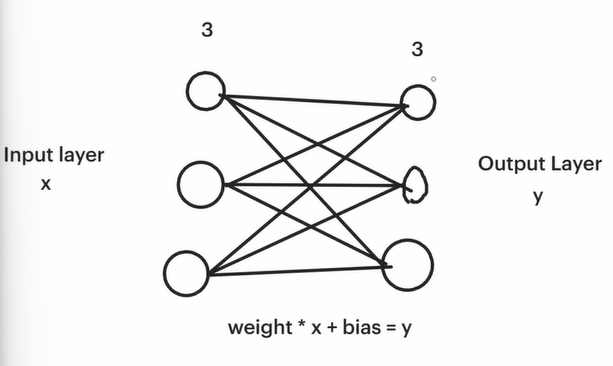

In [20]:
# Source - https://stackoverflow.com/a/37366154
# Posted by Oliver Wilken, modified by community. See post 'Timeline' for change history
# Retrieved 2026-04-24, License - CC BY-SA 4.0

from matplotlib import pyplot
from math import cos, sin, atan


class Neuron():
    def __init__(self, x, y):
        self.x = x
        self.y = y

    def draw(self, neuron_radius):
        circle = pyplot.Circle((self.x, self.y), radius=neuron_radius, fill=False)
        pyplot.gca().add_patch(circle)


class Layer():
    def __init__(self, network, number_of_neurons, number_of_neurons_in_widest_layer):
        self.vertical_distance_between_layers = 6
        self.horizontal_distance_between_neurons = 2
        self.neuron_radius = 0.5
        self.number_of_neurons_in_widest_layer = number_of_neurons_in_widest_layer
        self.previous_layer = self.__get_previous_layer(network)
        self.y = self.__calculate_layer_y_position()
        self.neurons = self.__intialise_neurons(number_of_neurons)

    def __intialise_neurons(self, number_of_neurons):
        neurons = []
        x = self.__calculate_left_margin_so_layer_is_centered(number_of_neurons)
        for iteration in xrange(number_of_neurons):
            neuron = Neuron(x, self.y)
            neurons.append(neuron)
            x += self.horizontal_distance_between_neurons
        return neurons

    def __calculate_left_margin_so_layer_is_centered(self, number_of_neurons):
        return self.horizontal_distance_between_neurons * (self.number_of_neurons_in_widest_layer - number_of_neurons) / 2

    def __calculate_layer_y_position(self):
        if self.previous_layer:
            return self.previous_layer.y + self.vertical_distance_between_layers
        else:
            return 0

    def __get_previous_layer(self, network):
        if len(network.layers) > 0:
            return network.layers[-1]
        else:
            return None

    def __line_between_two_neurons(self, neuron1, neuron2):
        angle = atan((neuron2.x - neuron1.x) / float(neuron2.y - neuron1.y))
        x_adjustment = self.neuron_radius * sin(angle)
        y_adjustment = self.neuron_radius * cos(angle)
        line = pyplot.Line2D((neuron1.x - x_adjustment, neuron2.x + x_adjustment), (neuron1.y - y_adjustment, neuron2.y + y_adjustment))
        pyplot.gca().add_line(line)

    def draw(self, layerType=0):
        for neuron in self.neurons:
            neuron.draw( self.neuron_radius )
            if self.previous_layer:
                for previous_layer_neuron in self.previous_layer.neurons:
                    self.__line_between_two_neurons(neuron, previous_layer_neuron)
        # write Text
        x_text = self.number_of_neurons_in_widest_layer * self.horizontal_distance_between_neurons
        if layerType == 0:
            pyplot.text(x_text, self.y, 'Input Layer', fontsize = 12)
        elif layerType == -1:
            pyplot.text(x_text, self.y, 'Output Layer', fontsize = 12)
        else:
            pyplot.text(x_text, self.y, 'Hidden Layer '+str(layerType), fontsize = 12)

class NeuralNetwork():
    def __init__(self, number_of_neurons_in_widest_layer):
        self.number_of_neurons_in_widest_layer = number_of_neurons_in_widest_layer
        self.layers = []
        self.layertype = 0

    def add_layer(self, number_of_neurons ):
        layer = Layer(self, number_of_neurons, self.number_of_neurons_in_widest_layer)
        self.layers.append(layer)

    def draw(self):
        pyplot.figure()
        for i in range( len(self.layers) ):
            layer = self.layers[i]
            if i == len(self.layers)-1:
                i = -1
            layer.draw( i )
        pyplot.axis('scaled')
        pyplot.axis('off')
        pyplot.title( 'Neural Network architecture', fontsize=15 )
        pyplot.show()

class DrawNN():
    def __init__( self, neural_network ):
        self.neural_network = neural_network

    def draw( self ):
        widest_layer = max( self.neural_network )
        network = NeuralNetwork( widest_layer )
        for l in self.neural_network:
            network.add_layer(l)
        network.draw()
